i.e. a static optimization but for the consumptions, a multi-objective optimization

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from solhycool_modeling import EnvironmentVariables
from solhycool_optimization import ValuesDecisionVariables, StaticResults, EvaluationConfig
from solhycool_optimization.problems.horizon.evaluation import generate_set_of_paretos
from phd_visualizations import save_figure
from IPython.display import Image

import combined_cooler
import matlab

%load_ext autoreload
%autoreload 2

results_path = Path("../results")

case_study_id = "pilot_plant_wct100" # Check case studies in `sim_config_path`

case_studies_dict = {
    "pilot_plant_wct100": {
        "Qnominal_kW": 200,
        "Tv_C": 35,
    },
    "andasol_wct100": {
        "Qnominal_kW": 95*10**3, # 95 MWth
        "Tv_C": 41.5,
    },
    "andasol_25_dc": {
        "Qnominal_kW": 95*10**3, # 95 MWth
        "Tv_C": 41.5,
    },
    "andasol_50_dc": {
        "Qnominal_kW": 95*10**3, # 95 MWth
        "Tv_C": 41.5,
    },
    "andasol_75_dc": {
        "Qnominal_kW": 95*10**3, # 95 MWth
        "Tv_C": 41.5,
    },
}

sim_config_path = "/workspaces/SOLhycool/simulation/data/simulations_config.json"

# Get simulation configuration
sim_config: EvaluationConfig = EvaluationConfig.from_config_file(sim_config_path, case_study_id)
cs = case_studies_dict[case_study_id]

# Compute decision variable arrays
dv_values=sim_config.vals_dec_vars.generate_arrays(sim_config.model_inputs_range)


## Debug a single evaluation

In [2]:
from solhycool_evaluation import SimulationConfig
from pathlib import Path
import pandas as pd

sim_id="andasol_pilot_plant_wct100"
sim_config_path = "/workspaces/SOLhycool/simulation/data/simulations_config.json"
env_path = "/workspaces/SOLhycool/data/datasets/"
output_path = "/workspaces/SOLhycool/simulation/results/"
date_str = "20220601"
idx_to_eval = np.arange(0, 5)

# Get simulation configuration
sim_config: SimulationConfig = SimulationConfig.from_config_file(sim_config_path, sim_id)

# Read environment
env_path = Path(env_path) / f"{sim_config.env_id}.h5"
df_env = pd.read_hdf(env_path).loc[date_str:date_str]
df_env = df_env[df_env["Q_kW"] > sim_config.power_threshold]

# Compute decision variable arrays
dv_values=sim_config.vals_dec_vars.generate_arrays(sim_config.model_inputs_range)

df_env[["Tamb_C", "HR_pct", "Tv_C", "Q_kW", "mv_kgh"]]


,Tamb_C,HR_pct,Tv_C,Q_kW,mv_kgh
2022-06-01 00:00:00+00:00,14.7,76,38.02,173.139762,258.55324
2022-06-01 07:00:00+00:00,14.3,81,41.51,203.829964,305.44116
2022-06-01 08:00:00+00:00,16.2,71,41.51,203.829964,305.44116
2022-06-01 09:00:00+00:00,18.2,60,41.51,203.829964,305.44116
2022-06-01 10:00:00+00:00,20.4,53,41.51,203.829964,305.44116
2022-06-01 11:00:00+00:00,22.4,47,41.51,203.829964,305.44116
2022-06-01 12:00:00+00:00,24.1,43,41.51,203.829964,305.44116
2022-06-01 13:00:00+00:00,25.5,39,41.51,203.829964,305.44116
2022-06-01 14:00:00+00:00,26.4,35,41.51,203.829964,305.44116
2022-06-01 15:00:00+00:00,26.9,34,41.51,203.829964,305.44116


In [4]:
paretos_set = generate_set_of_paretos(
    df_env=EnvironmentVariables(
        Tamb=df_env["Tamb_C"].iloc[idx_to_eval],
        HR=df_env["HR_pct"].iloc[idx_to_eval],
        Q=df_env["Q_kW"].iloc[idx_to_eval],
        Tv=df_env["Tv_C"].iloc[idx_to_eval],
    ).to_dataframe(
        index=list(df_env.index[idx_to_eval])
    ),
    n_parallel_evals=20,
    dv_values=dv_values,
    eval_config=sim_config,
)
paretos_set.visualize()


Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

2025-09-19 21:08:05.846 | DEBUG    | solhycool_optimization.problems.horizon.evaluation:get_pareto_front:156 - 20220601T0700 | Pareto front indices: [ 3 10 11 12 13 14 15 16 17 18 20 21]
2025-09-19 21:08:10.468 | DEBUG    | solhycool_optimization.problems.horizon.evaluation:get_pareto_front:156 - 20220601T0800 | Pareto front indices: [ 3  9 10 11 12 13 14 15 16 17 18 19 20 21]
2025-09-19 21:08:14.553 | DEBUG    | solhycool_optimization.problems.horizon.evaluation:get_pareto_front:156 - 20220601T0900 | Pareto front indices: [ 3  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
2025-09-19 21:08:18.541 | DEBUG   

## Test matlab evaluate_decision_variables (not used)

In [ ]:
cc_model = combined_cooler.initialize()

ev = EnvironmentVariables(
    Tamb=[30.8],
    HR=[39.3],
    Q=[0.8*cs["Qnominal_kW"]],
    Tv=[45],
)
dv_values = ValuesDecisionVariables.initialize(5).generate_arrays()
matlab_options = cs["matlab_options"]
date_str = "20010101"

cc_model.evaluate_decision_variables(0, ev.to_matlab_dict(), dv_values.to_matlab_dict(), date_str, matlab_options)


## Test a single evaluation

In [2]:
paretos_set = generate_set_of_paretos(
    df_env=EnvironmentVariables(
        Tamb=[30.8],
        HR=[39.3],
        Q=[0.8*cs["Qnominal_kW"]],
        Tv=[45],
    ).to_dataframe(
        index=pd.to_datetime([
            '2005-06-23 13:00:00+02:00', 
        ])
    ),
    n_parallel_evals=20,
    dv_values=ValuesDecisionVariables.initialize(6).generate_arrays(),
    matlab_options=cs["matlab_options"],
)


2025-09-19 17:18:37.015 | INFO     | solhycool_optimization:initialize:94 - Initializing ValuesDecisionVariables with 6 values per decision variable. A total of 1296 combinations will be generated.


KeyError: 'matlab_options'

## Multiple scenarios

In [5]:
df_env = EnvironmentVariables(
    Tamb = [45]*5,
    HR = [60]*5,
    Q = [200]*5,
    Tv = np.linspace(41, 44, 5)
    # Tamb=[45, 45, 10, 10], #, 40, 40],
    # HR=[60, 60, 70, 70], #, 50, 50],
    # Q=np.array([1, 0.7, 1, 0.7])*cs["Qnominal_kW"], # 1, 0.6] 
    # Tv=[cs["Tv_C"]]*4 # [42]*4 + [55]*2,
).to_dataframe(
    index=pd.to_datetime(['2005-06-23 13:00:00+02:00']*5)
    #     '2005-06-23 13:00:00+02:00', 
    #     '2005-06-23 13:01:00+02:00', 
    #     '2005-12-21 14:00:00+02:00', 
    #     '2005-12-21 14:01:00+02:00',
    #     # '2005-07-23 13:01:00+02:00',
    #     # '2005-07-23 13:01:00+02:00',
    # ])
)

df_env


,HR_pct,Tamb_C,Tv_C,Q_kW,Ce_spot_market_price_eur_kWh,Pw,water_price_eur_l,water_price_alternative_eur_l,Vavail_m3,deltaV_m3_h,mv_kgh
2005-06-23 13:00:00+02:00,60,45,41.00,200,None,None,None,None,None,None,299.549647
2005-06-23 13:00:00+02:00,60,45,41.75,200,None,None,None,None,None,None,299.773657
2005-06-23 13:00:00+02:00,60,45,42.50,200,None,None,None,None,None,None,299.998143
2005-06-23 13:00:00+02:00,60,45,43.25,200,None,None,None,None,None,None,300.223111
2005-06-23 13:00:00+02:00,60,45,44.00,200,None,None,None,None,None,None,300.448566


In [6]:
paretos_set = generate_set_of_paretos(
    df_env=df_env,
    n_parallel_evals=20,
    dv_values=dv_values,
    eval_config=sim_config,
)

paretos_set.export(results_path / f"paretos_set_for_different_scenarios_{case_study_id}.h5")
paretos_set.visualize()


Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

2025-09-19 18:21:25.810 | ERROR    | solhycool_optimization.problems.horizon.evaluation:evaluate_decision_variables:79 - 20050623 - step 00 | Not a single point was found during decision variables evaulation
2025-09-19 18:21:26.034 | ERROR    | solhycool_optimization.problems.horizon.evaluation:evaluate_decision_variables:79 - 20050623 - step 02 | Not a single point was found during decision variables evaulation
2025-09-19 18:21:26.171 | ERROR    | solhycool_optimization.problems.horizon.evaluation:evaluate_decision_variables:79 - 20050623 - step 03 | Not a single point was found during decision variables evaulation
2025-09-19 18:21:26.437 | ERROR    | solhycool_opti

In [8]:
paretos_set.df_paretos[0][["Ce_wct", "wwct", "qc", "Tcc_out"]]


,Ce_wct,wwct,qc,Tcc_out
0,1.599251,74.177738,24.000000,38.611962
1,1.617293,74.540726,23.632653,38.593349
2,1.626354,74.722220,23.265306,38.572936
3,1.644558,75.085208,22.897959,38.550938
4,1.662871,75.448195,22.530612,38.527533
5,1.672068,75.629689,22.163265,38.502817
6,1.699821,76.174171,21.428571,38.450239


2025-07-24 18:17:01.039 | INFO     | phd_visualizations:save_figure:41 - Figure saved in ../results/pareto_fronts_for_different_scenarios.png


FigureWidgetResampler({
    'data': [{'fill': 'tozeroy',
              'hovertemplate': '%{y:.2f}',
              'legend': 'legend',
              'line': {'color': '#83b366', 'width': 3},
              'mode': 'lines',
              'name': 'Q̇<sub>dc</sub>',
              'showlegend': True,
              'stackgroup': 'cooling_power_distribution',
              'type': 'scatter',
              'uid': '87065178-7927-447c-97e4-453b22aa415c',
              'x': array([  0.        ,   4.43637559,   7.07459919,  15.09610047,  21.82540229,
                           23.3422207 ,  26.39789685,  28.24269607,  30.4338843 ,  36.05195908,
                           45.09841018,  46.60295011,  49.04119912,  56.49223503,  67.6424817 ,
                           80.40876004,  80.96719373,  81.83051945,  88.75551245,  95.17616061,
                           97.93768518, 105.2552538 , 115.67174322, 125.41339692, 135.77041896,
                          142.81083665, 153.76232084, 163.44282682, 232.

2025-07-24 18:17:01.313 | INFO     | phd_visualizations:save_figure:41 - Figure saved in ../results/power_and_hydraulic_dist_for_different_scenarios.png


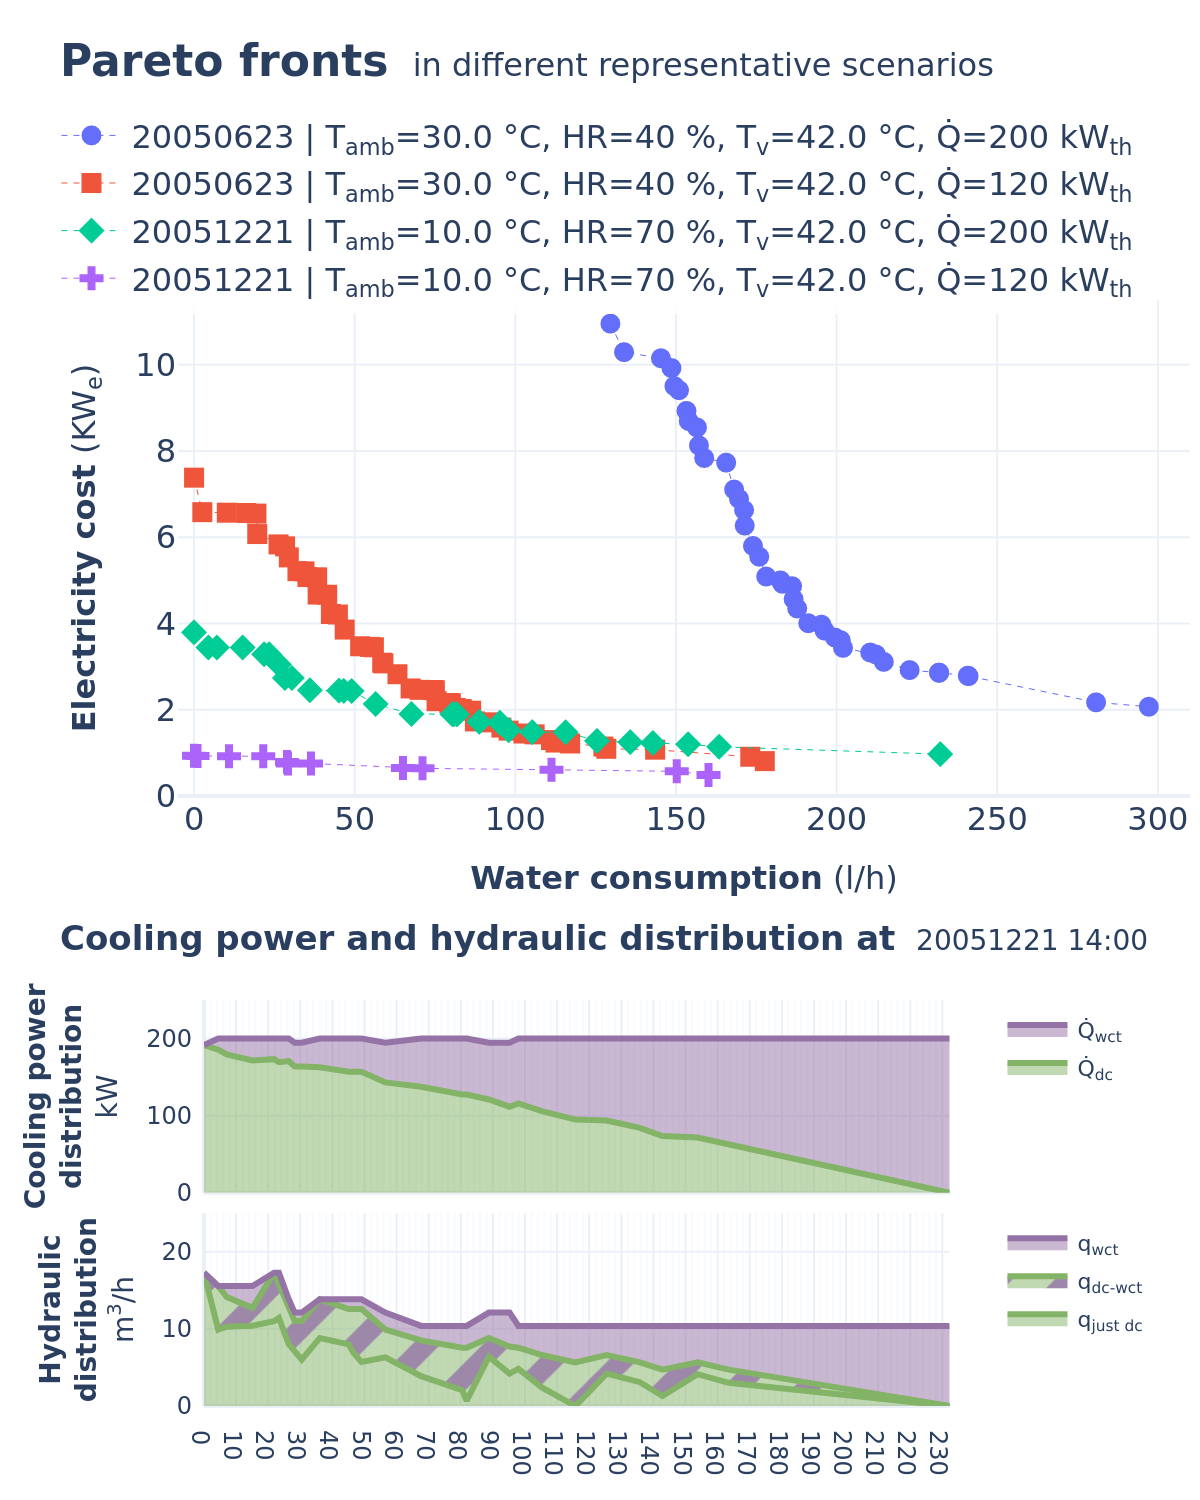

In [ ]:
from solhycool_visualization.optimization import plot_pareto_front
from phd_visualizations.test_timeseries import experimental_results_plot
from phd_visualizations.utils import stack_images_vertically

selected_pareto_idx = 2
figure_top_name = f"pareto_fronts_for_different_scenarios_{case_study_id}"
figure_bottom_name = f"power_and_hydraulic_dist_for_different_scenarios_{case_study_id}"

paretos_set2 = StaticResults.initialize(results_path / f"paretos_set_for_different_scenarios_{case_study_id}.h5")
df = paretos_set2.df_paretos[selected_pareto_idx].sort_values(by="Cw", ascending=True).set_index("Cw")
# df


fig = plot_pareto_front(
    ops_list=paretos_set2.df_paretos,
    full_legend=True,
    showlegend=True,
    date_fmt='%Y%m%d',
    objective_keys=('Cw', 'Ce'),
    yaxis_label="<b>Electricity cost</b> (KW<sub>e</sub>)",
    xaxis_label="<b>Water consumption</b> (l/h)",
    mode="overlap",
    simple_colors=True,
    template="plotly_white",
    title_text="<b>Pareto fronts</b> <span style='font-size:16px'> in different representative scenarios</span>",
    title_y=0.95,
    legend=dict(
        yanchor="top",
        xanchor="left",
        x=0.01,
        y=1.4,
    ),
    margin=dict(t=150, b=5, l=20, r=5),
    width=600,
    xaxis_range=[-5, 310],
    xaxis_domain=[0.12, 1],
)

save_figure(
    fig,
    figure_path=results_path,
    figure_name=figure_top_name,
    # formats=["html", "png", "svg"]
    formats=["png"]
)

display(fig)

plt_config = {
    "height": 300,
    "width": 600,
    "margin": {
        "l": 20,
        "r": 20,
        "t": 50,
        "b": 20,
        "pad": 5
    },
    "vertical_spacing": 0.05,
    "xminor": True,
    "xaxis_nticks": 24,

    "plots": {
        "cooling_power_distribution": {
            "row_height": 1,
            # "bg_color": "bg_gray",
            "ylabels_left": ["<b>Cooling power<br>distribution</b><br>kW"],
            "showlegend": True,  
            "legend_position": "side",
            "ylims_left": [0, 250],
            "traces_left": [
                {
                    "var_id": "Qdc",
                    "name": "Q̇<sub>dc</sub>",
                    "mode": "lines",
                    "color": "dc_green",
                    "width": 3,
                    "fill": "tozeroy",
                    "stackgroup": "cooling_power_distribution",
                    "showlegend": True,
                },
                {
                    "var_id": "Qwct",
                    "name": "Q̇<sub>wct</sub>",
                    "mode": "lines",
                    "color": "wct_purple",
                    "width": 3,
                    "fill": "tonexty",
                    "stackgroup": "cooling_power_distribution",
                    "showlegend": True,
                },
            ],
        },
        "hydraulic_distribution": {
            "row_height": 1,
            # "bg_color": "bg_gray",
            "ylabels_left": ["<b>Hydraulic<br>distribution</b><br>m<sup>3</sup>/h"],
            "ylims_left": [0, 25],
            "showlegend": True,
            "legend_position": "side",

            "traces_left": [
                {
                    "var_id": "qdc_only",
                    "name": "q<sub>just dc</sub>",
                    "mode": "lines",
                    "color": "dc_green",
                    "width": 3,
                    "fill": "tozeroy",
                    "stackgroup": "hydraulic_distribution",
                    "showlegend": True,
                },
                {
                    "var_id": "qwct_s",
                    "name": "q<sub>dc-wct</sub>",
                    "mode": "lines",
                    "color": "dc_green",
                    "width": 3,
                    "fill": "tonexty",
                    "stackgroup": "hydraulic_distribution",
                    "kwargs": {
                        "fillpattern_shape": "/", 
                        "fillpattern_fgcolor": "#9573a6",
                        "fillpattern_size": 25,
                        "fillpattern_fgopacity": 0.8,
                        "fillpattern_solidity": 0.4,
                    },
                    "showlegend": True,
                },
                {
                    "var_id": "qwct_p",
                    "name": "q<sub>wct</sub>",
                    "mode": "lines",
                    "color": "wct_purple",
                    "width": 3,
                    "fill": "tonexty",
                    "stackgroup": "hydraulic_distribution",
                    "showlegend": True,
                },
            ],
        },
        
    },
    "xdomain": [0, 0.78],
}

fig2 = experimental_results_plot(
    plt_config=plt_config, 
    df=df, template="plotly_white",
    title_text=f"<b>Cooling power and hydraulic distribution at </b><span style='font-size:14px'> {paretos_set2.index[selected_pareto_idx]:%Y%m%d %H:%M}</span>",
)

display(fig2)

save_figure(
    fig2,
    figure_path=results_path,
    figure_name=figure_bottom_name,
    formats=["png"]
)

stack_images_vertically(
    image_path_top=results_path / f"{figure_top_name}.png",
    image_path_bottom=results_path / f"{figure_bottom_name}.png",
    output_path=results_path / f"{figure_top_name}_and_{figure_bottom_name}.png"
)

display(Image(results_path / f"{figure_top_name}_and_{figure_bottom_name}.png"))

